# ST3189: Machine Learning — Assessed Coursework Project
**Candidate Number:** `[YOUR CANDIDATE NUMBER]`

---

### Structure
| Section | Task | Dataset | Models |
|---------|------|---------|--------|
| 1 | Unsupervised Learning | FIFA Players | K-Means, Hierarchical Agglomerative Clustering (HAC) |
| 2 | Supervised Learning (Classification) | Mushrooms | Logistic Regression, SVC, Random Forest |
| 3 | Supervised Learning (Regression) | FIFA Players | Linear, Polynomial, Lasso, Ridge, Random Forest |

> **Data sources**
> - FIFA dataset: `fifa_player_performance_market_value.csv`
> - Mushroom dataset: `mushrooms.csv` (UCI ML Repository — https://archive.ics.uci.edu/ml/datasets/mushroom)


---
## Setup & Imports

In [1]:
# ── Standard libraries ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

# ── Sklearn: preprocessing ────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA   # used only for 2D visualisation of clusters

# ── Sklearn: clustering ───────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

# ── Sklearn: models ───────────────────────────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV,
    LogisticRegression
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV
)

# ── Plot aesthetics ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif',
    'figure.facecolor': 'white'
})
PALETTE = sns.color_palette("Set2")
sns.set_palette("Set2")

print("✓ All libraries loaded successfully.")

✓ All libraries loaded successfully.


In [2]:
# ── Load datasets ─────────────────────────────────────────────────────────
fifa     = pd.read_csv('fifa_player_performance_market_value.csv')
mushroom = pd.read_csv('mushrooms.csv')

print(f"FIFA dataset    : {fifa.shape[0]:,} rows × {fifa.shape[1]} columns")
print(f"Mushroom dataset: {mushroom.shape[0]:,} rows × {mushroom.shape[1]} columns")
print()
display(fifa.head(3))
display(mushroom.head(3))

FIFA dataset    : 2,800 rows × 16 columns
Mushroom dataset: 8,124 rows × 23 columns



,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


---
## 1. Unsupervised Learning

**Research question:** Can data-driven clustering techniques identify natural, homogeneous
archetypes of professional football players based on their performance and market
characteristics, without relying on pre-defined labels?


### 1.2 Data Description

In [3]:
# Features selected for clustering (numeric only — drop ID, name, categoricals)
CLUSTER_FEATS = [
    'age', 'overall_rating', 'potential_rating',
    'matches_played', 'goals', 'assists',
    'minutes_played', 'market_value_million_eur', 'contract_years_left'
]

X_raw = fifa[CLUSTER_FEATS].dropna().copy()
print(f"Clustering dataset: {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features")
print("\nMissing values per feature:")
print(X_raw.isnull().sum())
print("\nDescriptive statistics:")
display(X_raw.describe().round(2))

Clustering dataset: 2,800 rows × 9 features

Missing values per feature:
age                         0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
dtype: int64

Descriptive statistics:


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00
mean,27.95,76.87,81.56,27.14,19.26,12.02,2250.10,90.57,2.53
std,6.75,9.92,9.76,15.98,11.57,7.19,1295.46,52.08,1.70
min,17.00,60.00,65.00,0.00,0.00,0.00,0.00,0.67,0.00
25%,22.00,68.00,73.00,13.75,9.00,6.00,1131.25,45.36,1.00
50%,28.00,77.00,82.00,27.00,19.00,12.00,2251.00,89.17,3.00
75%,34.00,85.00,90.00,41.00,30.00,18.00,3366.25,136.68,4.00
max,39.00,94.00,98.00,54.00,39.00,24.00,4497.00,179.96,5.00


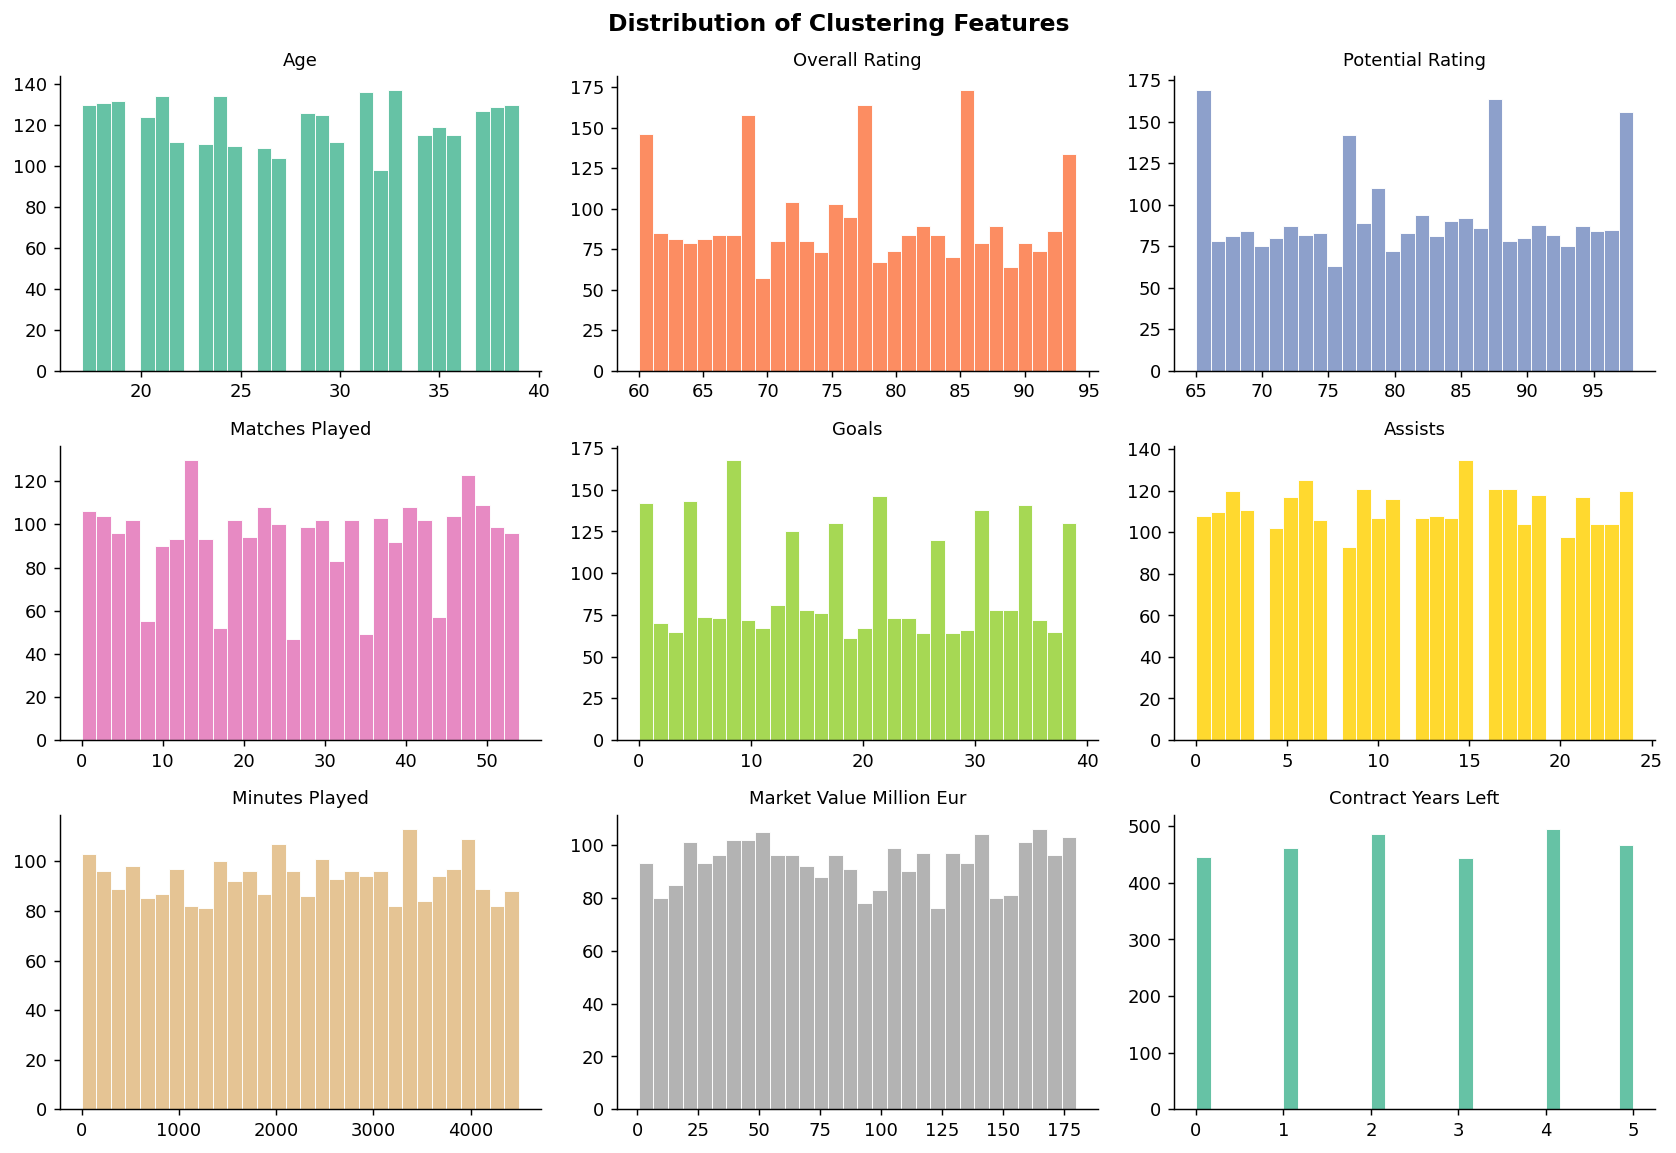

Saved: fig1_feature_distributions.png


In [4]:
# ── Distribution of clustering features ──────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(CLUSTER_FEATS):
    axes[i].hist(X_raw[feat], bins=30, color=PALETTE[i % len(PALETTE)],
                 edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=10)

plt.suptitle('Distribution of Clustering Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_feature_distributions.png', bbox_inches='tight')
plt.show()
print("Saved: fig1_feature_distributions.png")

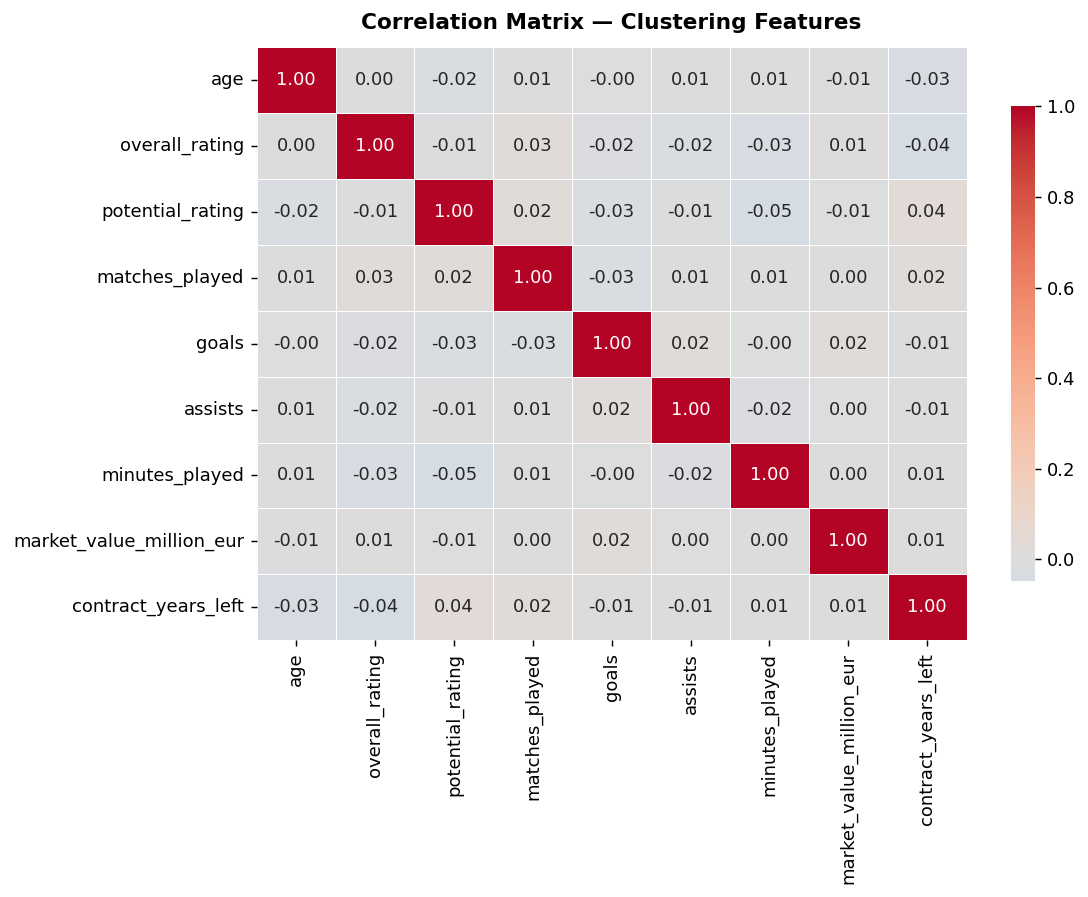

Saved: fig1_correlation_heatmap.png


In [5]:
# ── Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(X_raw.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Clustering Features', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig1_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: fig1_correlation_heatmap.png")

In [6]:
# ── Z-score standardisation ───────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Post-scaling means  (should be ~0):", np.round(X_scaled.mean(axis=0), 3))
print("Post-scaling stdevs (should be ~1):", np.round(X_scaled.std(axis=0),  3))

Post-scaling means  (should be ~0): [-0.  0. -0. -0. -0. -0. -0. -0. -0.]
Post-scaling stdevs (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 1.3.2 K-Means Clustering

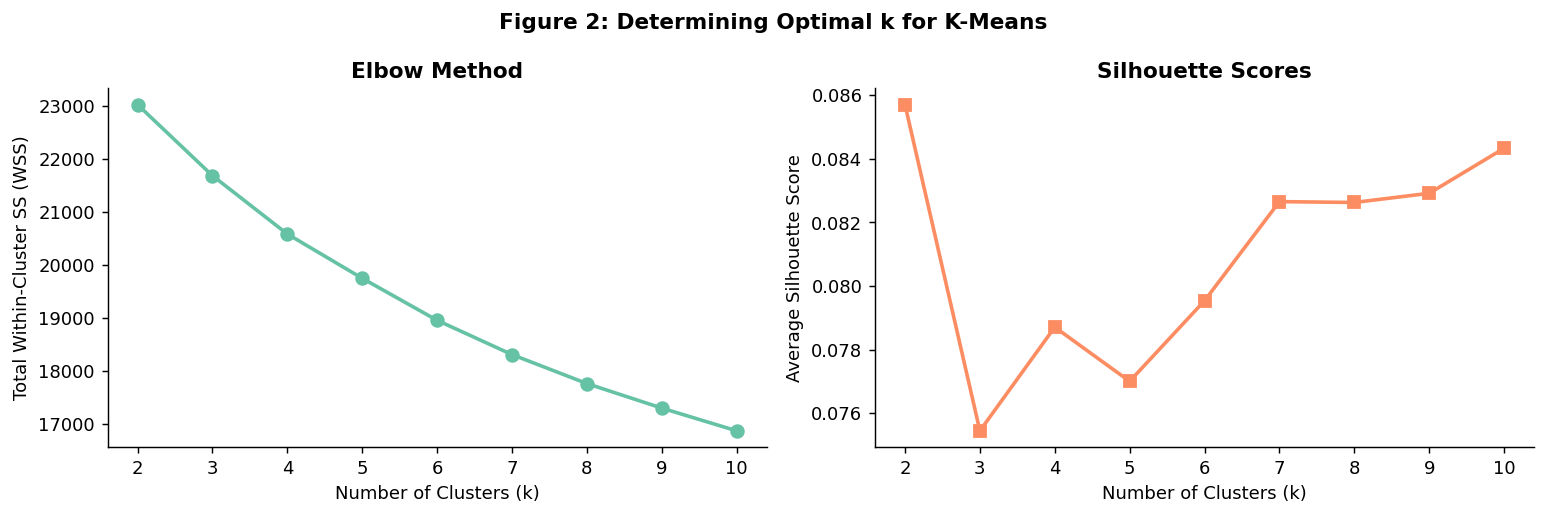

   k           WSS    Silhouette
--------------------------------
   2       23023.6        0.0857  ◄ best silhouette
   3       21684.7        0.0755
   4       20585.1        0.0787
   5       19749.8        0.0770
   6       18957.8        0.0795
   7       18311.9        0.0827
   8       17765.5        0.0826
   9       17303.1        0.0829
  10       16874.2        0.0843


In [7]:
# ── Elbow Method + Silhouette Scores to find optimal k ────────────────────
wss        = []
sil_scores = []
K_RANGE    = range(2, 11)

for k in K_RANGE:
    km  = KMeans(n_clusters=k, n_init=25, random_state=42)
    lbl = km.fit_predict(X_scaled)
    wss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_RANGE, wss, 'o-', color=PALETTE[0], linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Total Within-Cluster SS (WSS)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(K_RANGE, sil_scores, 's-', color=PALETTE[1], linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].set_title('Silhouette Scores', fontweight='bold')
axes[1].set_xticks(list(K_RANGE))

plt.suptitle('Figure 2: Determining Optimal k for K-Means',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_elbow_silhouette.png', bbox_inches='tight')
plt.show()

print(f"{'k':>4}  {'WSS':>12}  {'Silhouette':>12}")
print("-" * 32)
for k, w, s in zip(K_RANGE, wss, sil_scores):
    star = "  ◄ best silhouette" if s == max(sil_scores) else ""
    print(f"{k:>4}  {w:>12.1f}  {s:>12.4f}{star}")

In [8]:
# ── Set optimal k based on elbow/silhouette output above ─────────────────
# UPDATE this value after inspecting the plots
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, n_init=25, random_state=42)
cluster_df = X_raw.copy()
cluster_df['kmeans_cluster'] = km_final.fit_predict(X_scaled)

print(f"K-Means fitted with K_OPTIMAL = {K_OPTIMAL}")
print("\nCluster sizes:")
print(cluster_df['kmeans_cluster'].value_counts().sort_index())

K-Means fitted with K_OPTIMAL = 4

Cluster sizes:
kmeans_cluster
0    736
1    704
2    652
3    708
Name: count, dtype: int64


In [9]:
# ── Cluster centroids back-transformed to original scale ─────────────────
centroids = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=CLUSTER_FEATS
).round(2)
centroids.index.name = 'Cluster'
print("=== Cluster Centroids (Original Scale) ===")
display(centroids)

# Label clusters based on centroid inspection — update after running
CLUSTER_LABELS = {i: f'Cluster {i}' for i in range(K_OPTIMAL)}
# Example after inspecting centroids:
# CLUSTER_LABELS = {0: 'Elite Veterans', 1: 'High-Potential Youth',
#                   2: 'Solid Contributors', 3: 'Squad Depth'}

=== Cluster Centroids (Original Scale) ===


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
Cluster,,,,,,,,,
0,29.98,78.30,72.11,27.35,20.18,13.93,2423.14,97.34,1.39
1,27.43,74.33,86.19,28.19,19.24,19.07,2222.20,92.96,3.51
2,26.52,78.94,89.17,27.23,18.86,8.90,1903.92,83.44,1.05
3,27.69,76.01,79.77,25.77,18.71,5.84,2416.15,87.68,4.09


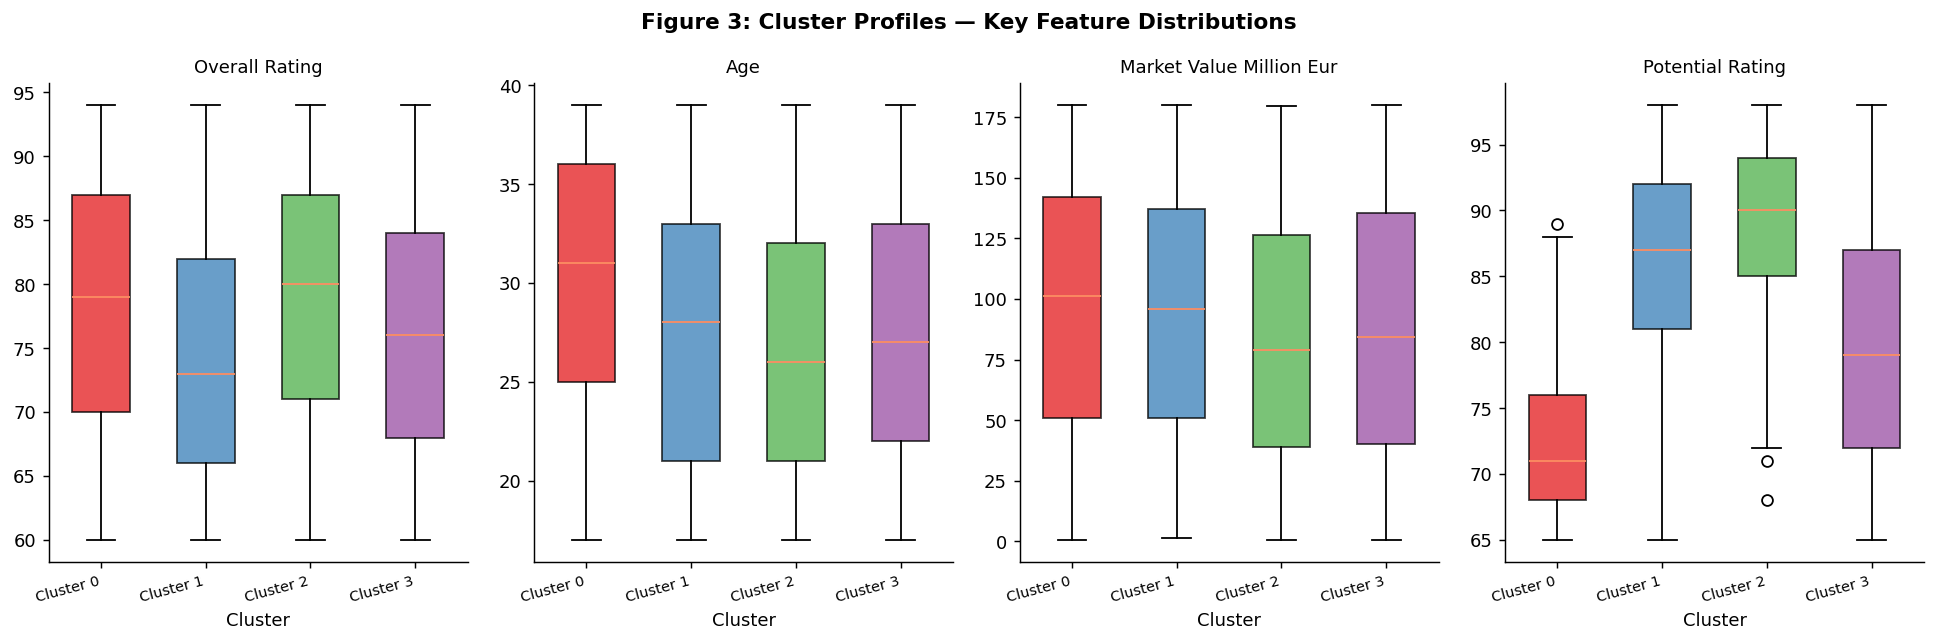

Saved: fig3_cluster_boxplots.png


In [10]:
# ── Cluster profile boxplots (key features) ───────────────────────────────
KEY_FEATS = ['overall_rating', 'age', 'market_value_million_eur', 'potential_rating']
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
pal = sns.color_palette("Set1", K_OPTIMAL)

for ax, feat in zip(axes, KEY_FEATS):
    data = [cluster_df.loc[cluster_df['kmeans_cluster'] == c, feat].values
            for c in range(K_OPTIMAL)]
    bp = ax.boxplot(data, patch_artist=True, notch=False, widths=0.55)
    for patch, color in zip(bp['boxes'], pal):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_xticklabels([CLUSTER_LABELS[c] for c in range(K_OPTIMAL)],
                       rotation=15, ha='right', fontsize=8)

plt.suptitle('Figure 3: Cluster Profiles — Key Feature Distributions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_cluster_boxplots.png', bbox_inches='tight')
plt.show()
print("Saved: fig3_cluster_boxplots.png")

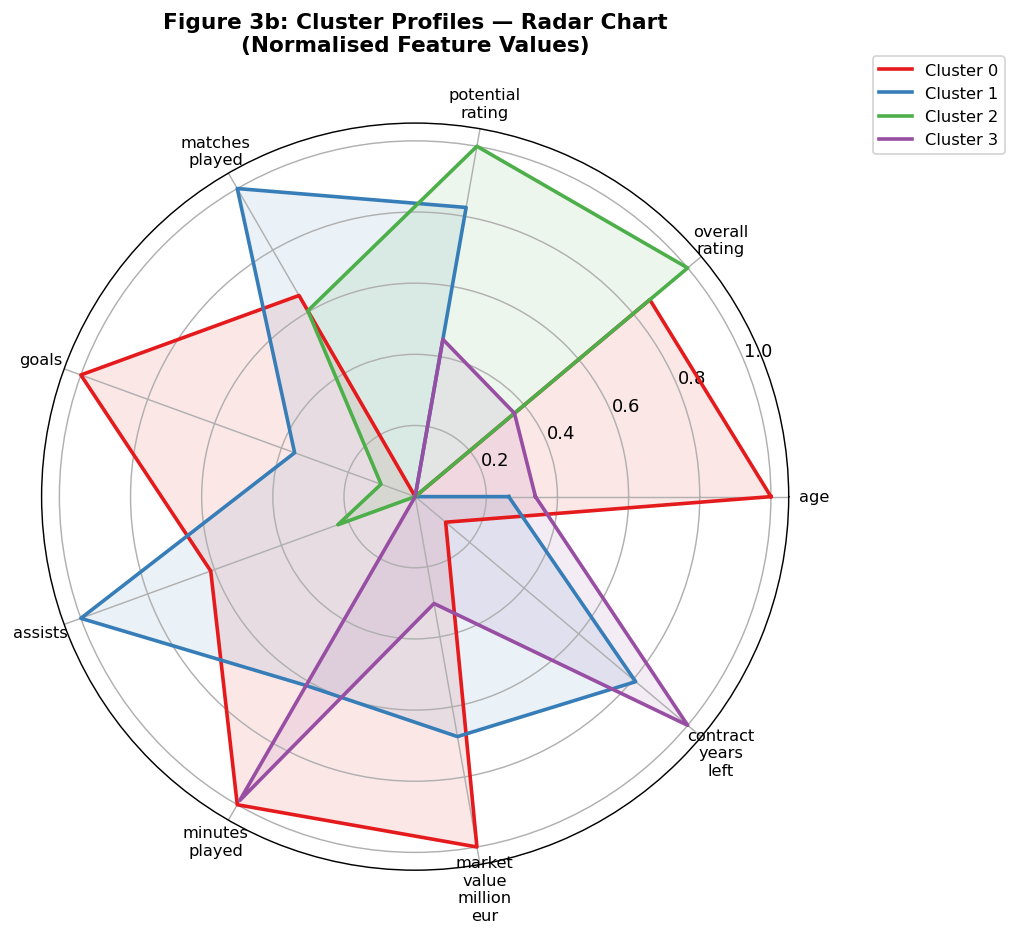

Saved: fig3b_cluster_radar.png


In [11]:
# ── Radar chart of cluster centroids (normalised to 0-1 per feature) ──────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalise centroids to 0-1 scale for radar
norm_centroids = (centroids - centroids.min()) / (centroids.max() - centroids.min())
categories = CLUSTER_FEATS
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
pal = sns.color_palette("Set1", K_OPTIMAL)

for c in range(K_OPTIMAL):
    values = norm_centroids.iloc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, color=pal[c],
            label=CLUSTER_LABELS[c])
    ax.fill(angles, values, alpha=0.1, color=pal[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', '\n') for f in categories], fontsize=9)
ax.set_title('Figure 3b: Cluster Profiles — Radar Chart\n(Normalised Feature Values)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('fig3b_cluster_radar.png', bbox_inches='tight')
plt.show()
print("Saved: fig3b_cluster_radar.png")

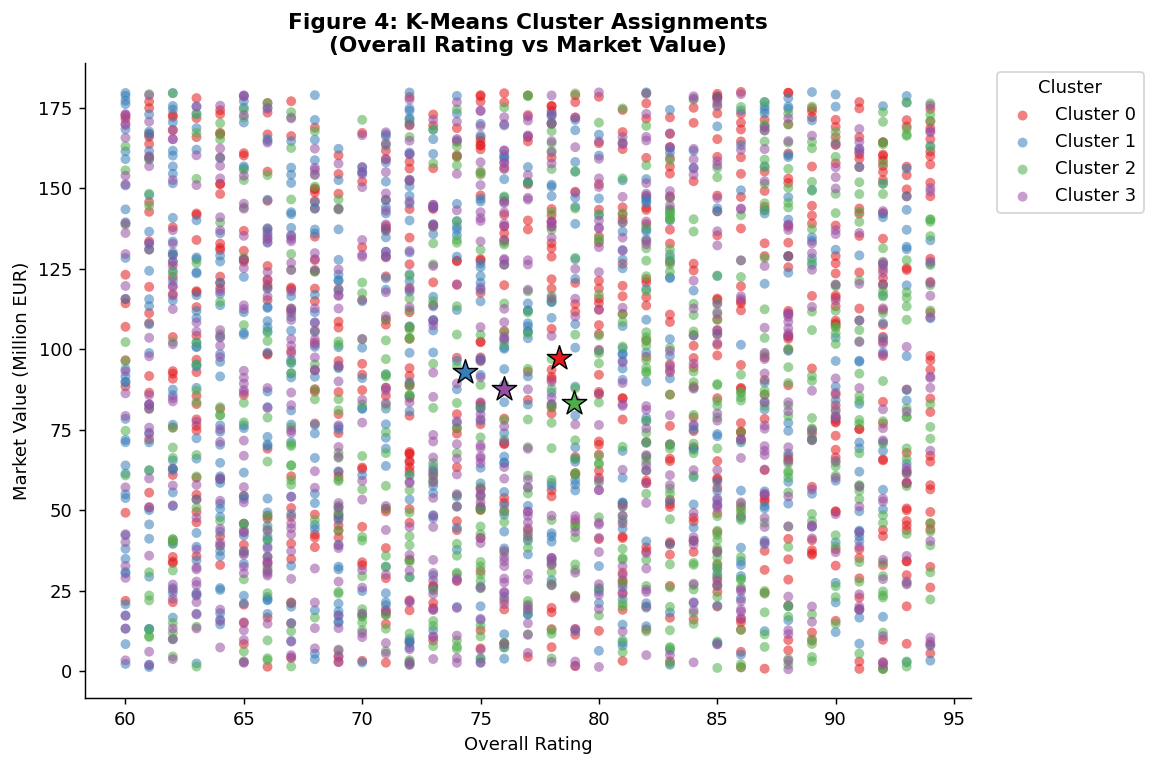

Saved: fig4_kmeans_scatter.png


In [12]:
# ── 2D scatter using first 2 features with highest variance for visualisation
# (alternative to PCA — uses actual feature axes that are interpretable)
# Uses overall_rating vs market_value as the two most meaningful axes

fig, ax = plt.subplots(figsize=(9, 6))
pal = sns.color_palette("Set1", K_OPTIMAL)

for c in range(K_OPTIMAL):
    mask = cluster_df['kmeans_cluster'] == c
    ax.scatter(
        cluster_df.loc[mask, 'overall_rating'],
        cluster_df.loc[mask, 'market_value_million_eur'],
        c=[pal[c]], label=CLUSTER_LABELS[c],
        alpha=0.55, s=30, edgecolors='none'
    )

# Plot centroids
for c in range(K_OPTIMAL):
    ax.scatter(centroids.loc[c, 'overall_rating'],
               centroids.loc[c, 'market_value_million_eur'],
               c=[pal[c]], s=200, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)

ax.set_xlabel('Overall Rating')
ax.set_ylabel('Market Value (Million EUR)')
ax.set_title('Figure 4: K-Means Cluster Assignments\n(Overall Rating vs Market Value)',
             fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig4_kmeans_scatter.png', bbox_inches='tight')
plt.show()
print("Saved: fig4_kmeans_scatter.png")

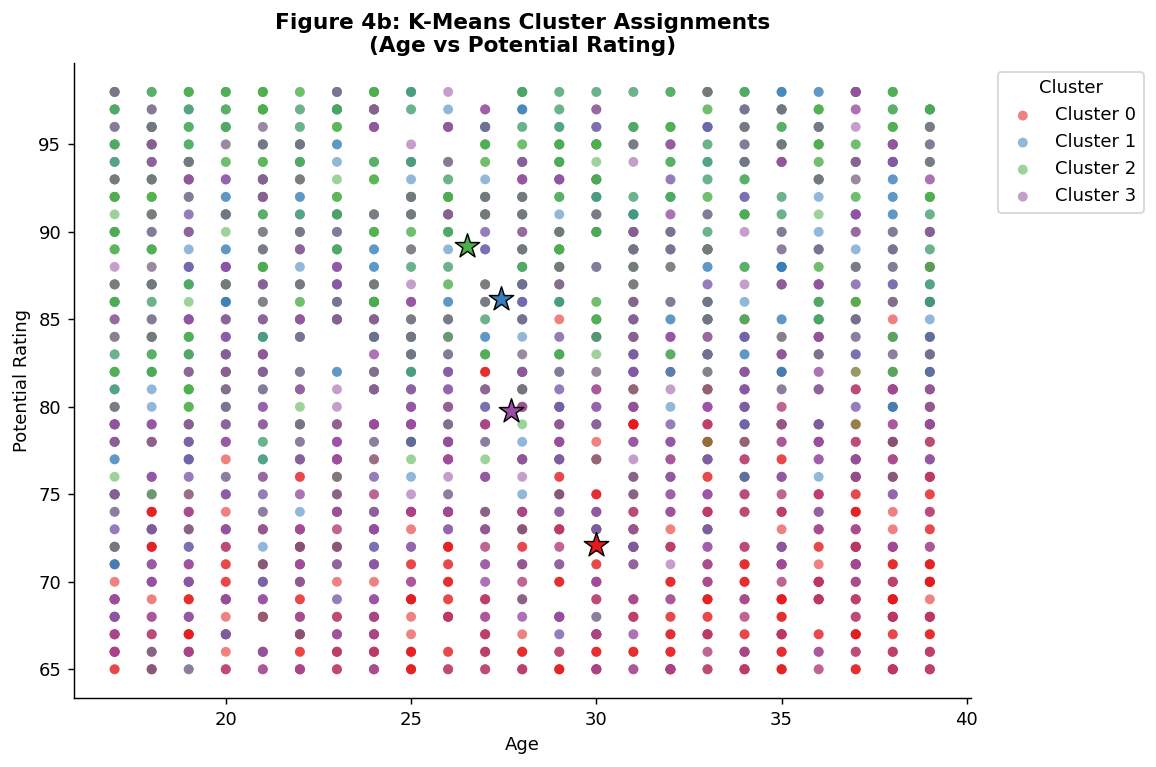

Saved: fig4b_kmeans_age_potential.png


In [13]:
# ── Additional scatter: Age vs Potential Rating ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for c in range(K_OPTIMAL):
    mask = cluster_df['kmeans_cluster'] == c
    ax.scatter(
        cluster_df.loc[mask, 'age'],
        cluster_df.loc[mask, 'potential_rating'],
        c=[pal[c]], label=CLUSTER_LABELS[c],
        alpha=0.55, s=30, edgecolors='none'
    )

for c in range(K_OPTIMAL):
    ax.scatter(centroids.loc[c, 'age'],
               centroids.loc[c, 'potential_rating'],
               c=[pal[c]], s=200, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)

ax.set_xlabel('Age')
ax.set_ylabel('Potential Rating')
ax.set_title('Figure 4b: K-Means Cluster Assignments\n(Age vs Potential Rating)',
             fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig4b_kmeans_age_potential.png', bbox_inches='tight')
plt.show()
print("Saved: fig4b_kmeans_age_potential.png")

### 1.3.3 Hierarchical Agglomerative Clustering (HAC)

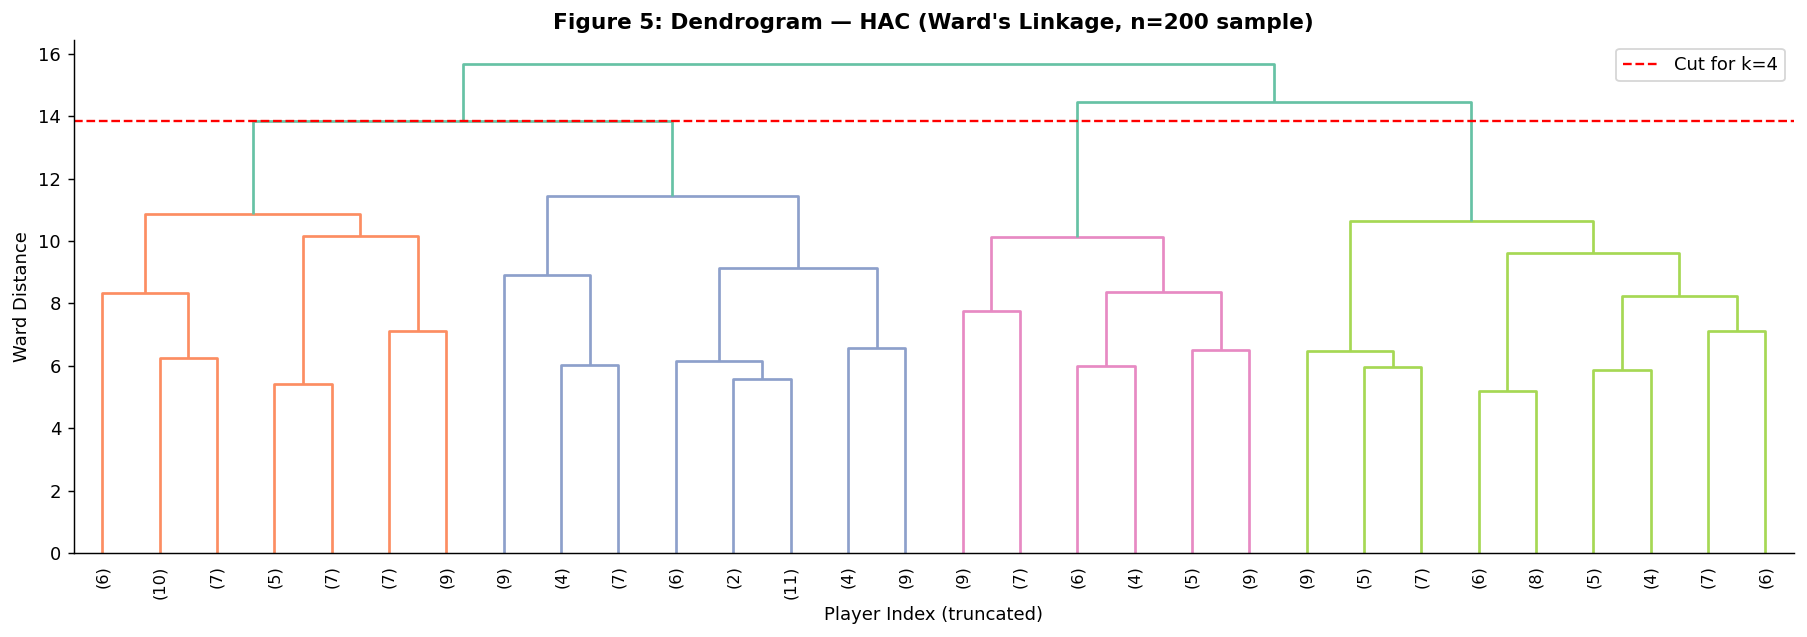

Saved: fig5_dendrogram.png


In [14]:
# ── Dendrogram on 200-player sample for legibility ────────────────────────
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=200, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

cut_height = Z[-(K_OPTIMAL - 1), 2]

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=cut_height)
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.3,
           label=f'Cut for k={K_OPTIMAL}')
ax.set_title("Figure 5: Dendrogram — HAC (Ward's Linkage, n=200 sample)",
             fontweight='bold')
ax.set_xlabel('Player Index (truncated)')
ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_dendrogram.png', bbox_inches='tight')
plt.show()
print("Saved: fig5_dendrogram.png")

In [15]:
# ── Fit HAC on full dataset ───────────────────────────────────────────────
hac = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
cluster_df['hac_cluster'] = hac.fit_predict(X_scaled)

print("HAC cluster sizes:")
print(cluster_df['hac_cluster'].value_counts().sort_index())

HAC cluster sizes:
hac_cluster
0    1006
1     644
2     535
3     615
Name: count, dtype: int64


### 1.4 Model Evaluation

In [16]:
# ── Adjusted Rand Index ───────────────────────────────────────────────────
ari = adjusted_rand_score(cluster_df['kmeans_cluster'], cluster_df['hac_cluster'])
print(f"Adjusted Rand Index (K-Means vs HAC): {ari:.4f}")
print("(ARI close to 1.0 = strong agreement between methods)")

# ── Silhouette scores ─────────────────────────────────────────────────────
km_sil = silhouette_score(X_scaled, cluster_df['kmeans_cluster'])
hc_sil = silhouette_score(X_scaled, cluster_df['hac_cluster'])

eval_df = pd.DataFrame({
    'Method':           ['K-Means', 'HAC (Ward)'],
    'Silhouette Score': [round(km_sil, 4), round(hc_sil, 4)],
    'Inertia (WSS)':    [round(km_final.inertia_, 1), '—'],
    'ARI vs other':     [round(ari, 4), round(ari, 4)]
})
print("\n=== Table 3: Clustering Evaluation Summary ===")
display(eval_df)

Adjusted Rand Index (K-Means vs HAC): 0.0666
(ARI close to 1.0 = strong agreement between methods)



=== Table 3: Clustering Evaluation Summary ===


,Method,Silhouette Score,Inertia (WSS),ARI vs other
0,K-Means,0.0787,20585.1,0.0666
1,HAC (Ward),0.0299,—,0.0666


In [17]:
# ── Cross-tabulation: K-Means vs HAC assignment agreement ────────────────
ct = pd.crosstab(cluster_df['kmeans_cluster'], cluster_df['hac_cluster'],
                 rownames=['K-Means'], colnames=['HAC'])
print("Cross-tabulation of K-Means vs HAC assignments:")
display(ct)

Cross-tabulation of K-Means vs HAC assignments:


HAC,0,1,2,3
K-Means,,,,
0,174,33,285,244
1,295,132,148,129
2,301,160,40,151
3,236,319,62,91


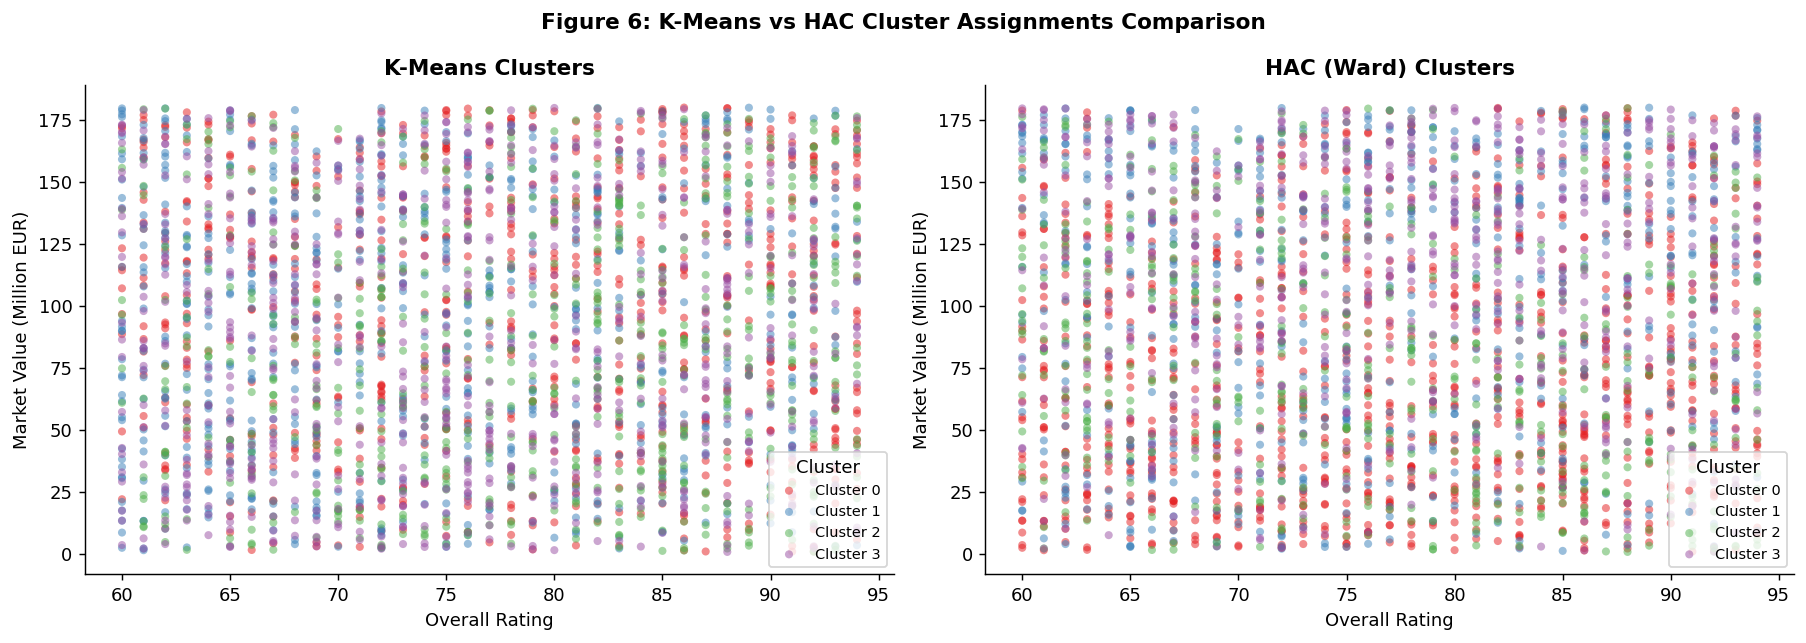

Saved: fig6_kmeans_vs_hac.png


In [18]:
# ── HAC cluster profile scatter: Overall Rating vs Market Value ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal = sns.color_palette("Set1", K_OPTIMAL)

for ax, (col, labels, title) in zip(axes, [
    ('kmeans_cluster', CLUSTER_LABELS, 'K-Means'),
    ('hac_cluster',    {i: f'Cluster {i}' for i in range(K_OPTIMAL)}, 'HAC (Ward)')
]):
    for c in range(K_OPTIMAL):
        mask = cluster_df[col] == c
        ax.scatter(cluster_df.loc[mask, 'overall_rating'],
                   cluster_df.loc[mask, 'market_value_million_eur'],
                   c=[pal[c]], label=labels[c],
                   alpha=0.5, s=20, edgecolors='none')
    ax.set_xlabel('Overall Rating')
    ax.set_ylabel('Market Value (Million EUR)')
    ax.set_title(f'{title} Clusters', fontweight='bold')
    ax.legend(title='Cluster', fontsize=8)

plt.suptitle('Figure 6: K-Means vs HAC Cluster Assignments Comparison',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_kmeans_vs_hac.png', bbox_inches='tight')
plt.show()
print("Saved: fig6_kmeans_vs_hac.png")

---
## 2. Supervised Learning (Classification)

**Research question:** Can the physical characteristics of a mushroom reliably predict whether
it is edible or poisonous — and which model achieves the best performance?

> **Priority metric:** Recall for the **poisonous class** — false negatives are safety-critical.


### 2.2 Dataset Description

Class counts:
class
e    4208
p    3916
Name: count, dtype: int64


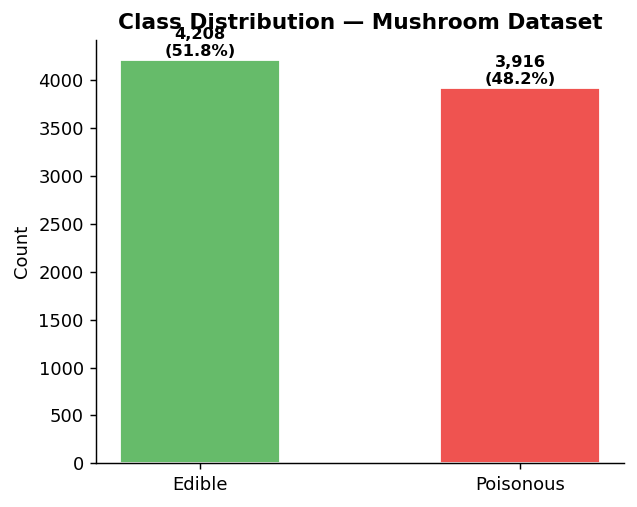

In [19]:
# ── Class distribution ────────────────────────────────────────────────────
print("Class counts:")
print(mushroom['class'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
counts = mushroom['class'].map({'e': 'Edible', 'p': 'Poisonous'}).value_counts()
ax.bar(counts.index, counts.values,
       color=['#66BB6A', '#EF5350'], edgecolor='white', width=0.5)
ax.set_ylabel('Count')
ax.set_title('Class Distribution — Mushroom Dataset', fontweight='bold')
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f'{v:,}\n({v/len(mushroom)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('fig_clf_class_dist.png', bbox_inches='tight')
plt.show()

In [20]:
# ── Unique values per feature ────────────────────────────────────────────
print("Unique values per feature:")
for col in mushroom.columns:
    print(f"  {col:38s}: {mushroom[col].nunique()} unique")

Unique values per feature:
  class                                 : 2 unique
  cap-shape                             : 6 unique
  cap-surface                           : 4 unique
  cap-color                             : 10 unique
  bruises                               : 2 unique
  odor                                  : 9 unique
  gill-attachment                       : 2 unique
  gill-spacing                          : 2 unique
  gill-size                             : 2 unique
  gill-color                            : 12 unique
  stalk-shape                           : 2 unique
  stalk-root                            : 5 unique
  stalk-surface-above-ring              : 4 unique
  stalk-surface-below-ring              : 4 unique
  stalk-color-above-ring                : 9 unique
  stalk-color-below-ring                : 9 unique
  veil-type                             : 1 unique
  veil-color                            : 4 unique
  ring-number                           : 3 unique
  

In [21]:
# ── Drop veil-type (single unique value — no discriminatory power) ────────
mush = mushroom.drop(columns=['veil-type']).copy()

# Encode target: 1 = poisonous, 0 = edible
mush['target'] = (mush['class'] == 'p').astype(int)
X_mush = pd.get_dummies(mush.drop(columns=['class', 'target']), drop_first=True)
y_mush = mush['target']

print(f"Feature matrix after one-hot encoding: {X_mush.shape}")
print(f"Class balance — poisonous: {y_mush.mean()*100:.1f}%")

Feature matrix after one-hot encoding: (8124, 95)
Class balance — poisonous: 48.2%


In [22]:
# ── Train / test split (stratified 80/20) ────────────────────────────────
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_mush, y_mush, test_size=0.2, stratify=y_mush, random_state=42
)
print(f"Training : {X_tr_m.shape[0]:,} | Test: {X_te_m.shape[0]:,}")

Training : 6,499 | Test: 1,625


### 2.4.1 Logistic Regression

In [23]:
# L2-regularised logistic regression (lbfgs solver, max 1000 iterations)
log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_tr_m, y_tr_m)

y_pred_lr_clf = log_reg.predict(X_te_m)
y_prob_lr_clf = log_reg.predict_proba(X_te_m)[:, 1]

print("Logistic Regression — Classification Report:")
print(classification_report(y_te_m, y_pred_lr_clf,
                             target_names=['Edible', 'Poisonous']))

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



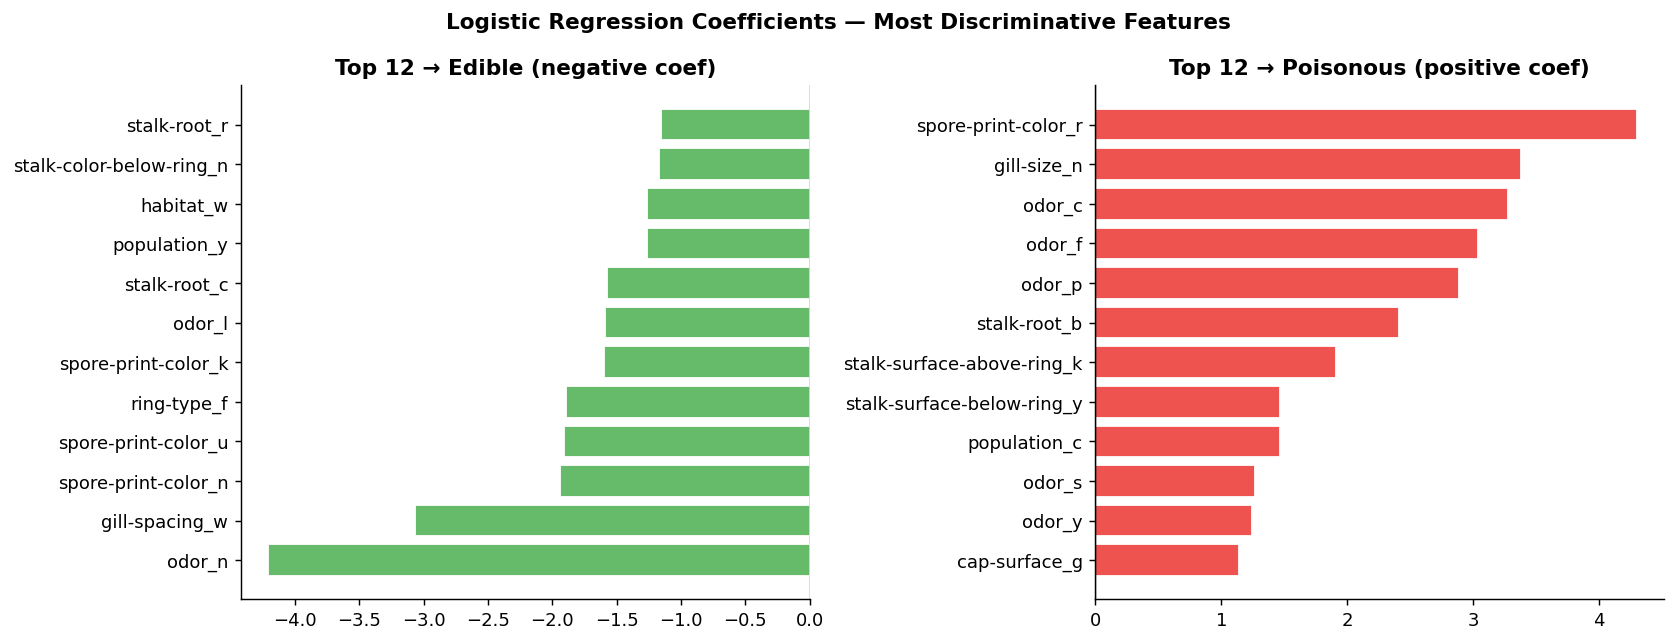

Saved: fig_lr_coefficients.png


In [24]:
# ── Top coefficients: most discriminative features ────────────────────────
coef_df = pd.DataFrame({
    'feature':     X_mush.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(coef_df.head(12)['feature'], coef_df.head(12)['coefficient'],
             color='#66BB6A', edgecolor='white')
axes[0].set_title('Top 12 → Edible (negative coef)', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.7)

axes[1].barh(coef_df.tail(12)['feature'], coef_df.tail(12)['coefficient'],
             color='#EF5350', edgecolor='white')
axes[1].set_title('Top 12 → Poisonous (positive coef)', fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.7)

plt.suptitle('Logistic Regression Coefficients — Most Discriminative Features',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lr_coefficients.png', bbox_inches='tight')
plt.show()
print("Saved: fig_lr_coefficients.png")

### 2.4.2 Support Vector Classification (SVC)

In [25]:
# ── Grid search: C and gamma with RBF kernel, scored by poisonous recall ──
param_grid = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

svc_base  = SVC(kernel='rbf', probability=True, random_state=42)
grid_svc  = GridSearchCV(svc_base, param_grid, cv=3,
                         scoring='recall', n_jobs=-1, verbose=0)
grid_svc.fit(X_tr_m, y_tr_m)

print(f"Best SVC params : {grid_svc.best_params_}")
print(f"Best CV Recall  : {grid_svc.best_score_:.4f}")

svc_best    = grid_svc.best_estimator_
y_pred_svc  = svc_best.predict(X_te_m)
y_prob_svc  = svc_best.predict_proba(X_te_m)[:, 1]

print("\nSVC — Classification Report:")
print(classification_report(y_te_m, y_pred_svc,
                             target_names=['Edible', 'Poisonous']))

Best SVC params : {'C': 1, 'gamma': 'scale'}
Best CV Recall  : 0.9984



SVC — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### 2.4.3 Random Forest Classifier

In [26]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_tr_m, y_tr_m)

y_pred_rf_clf = rf_clf.predict(X_te_m)
y_prob_rf_clf = rf_clf.predict_proba(X_te_m)[:, 1]

print("Random Forest — Classification Report:")
print(classification_report(y_te_m, y_pred_rf_clf,
                             target_names=['Edible', 'Poisonous']))

Random Forest — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



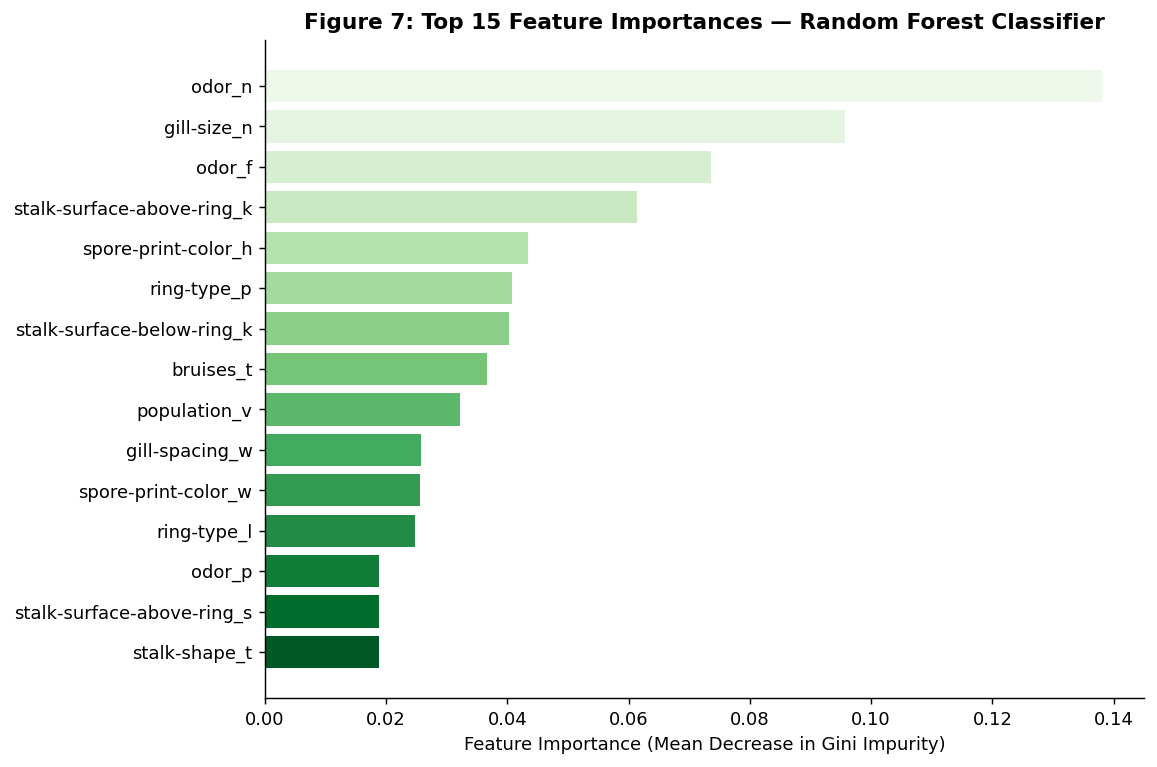

Saved: fig7_rf_feature_importance_clf.png


In [27]:
# ── Feature importance — top 15 ───────────────────────────────────────────
feat_imp_clf = pd.Series(
    rf_clf.feature_importances_, index=X_mush.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_clf.index, feat_imp_clf.values,
        color=sns.color_palette("Greens_r", 15))
ax.set_xlabel('Feature Importance (Mean Decrease in Gini Impurity)')
ax.set_title('Figure 7: Top 15 Feature Importances — Random Forest Classifier',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_rf_feature_importance_clf.png', bbox_inches='tight')
plt.show()
print("Saved: fig7_rf_feature_importance_clf.png")

### 2.5 Model Evaluation

In [28]:
# ── Metrics summary table ─────────────────────────────────────────────────
def clf_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model':         name,
        'Accuracy':      round(accuracy_score(y_true, y_pred), 4),
        'Precision (P)': round(precision_score(y_true, y_pred), 4),
        'Recall (P)':    round(recall_score(y_true, y_pred), 4),
        'F1 (P)':        round(f1_score(y_true, y_pred), 4),
        'AUC-ROC':       round(roc_auc_score(y_true, y_prob), 4)
    }

results_clf = pd.DataFrame([
    clf_metrics(y_te_m, y_pred_lr_clf,  y_prob_lr_clf,  'Logistic Regression'),
    clf_metrics(y_te_m, y_pred_svc,     y_prob_svc,     'SVC (RBF)'),
    clf_metrics(y_te_m, y_pred_rf_clf,  y_prob_rf_clf,  'Random Forest')
])

print("=== Table 4: Classification Performance (Test Set) ===")
display(results_clf.set_index('Model'))

=== Table 4: Classification Performance (Test Set) ===


,Accuracy,Precision (P),Recall (P),F1 (P),AUC-ROC
Model,,,,,
Logistic Regression,0.9988,1.0,0.9974,0.9987,1.0
SVC (RBF),1.0000,1.0,1.0000,1.0000,1.0
Random Forest,1.0000,1.0,1.0000,1.0000,1.0


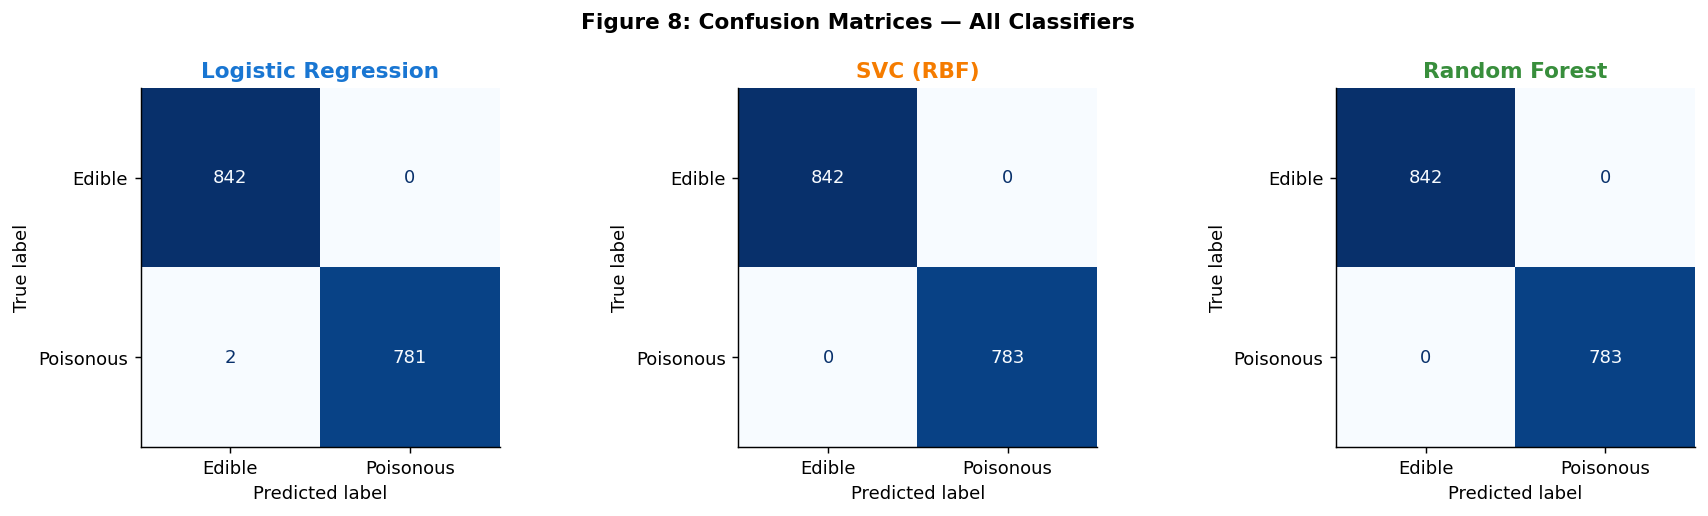

Saved: fig8_confusion_matrices.png


In [29]:
# ── Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
clf_info = [
    ('Logistic Regression', y_pred_lr_clf,  '#1976D2'),
    ('SVC (RBF)',            y_pred_svc,    '#F57C00'),
    ('Random Forest',        y_pred_rf_clf, '#388E3C')
]

for ax, (name, y_pred, color) in zip(axes, clf_info):
    cm   = confusion_matrix(y_te_m, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Edible', 'Poisonous'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', color=color)

plt.suptitle('Figure 8: Confusion Matrices — All Classifiers',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: fig8_confusion_matrices.png")

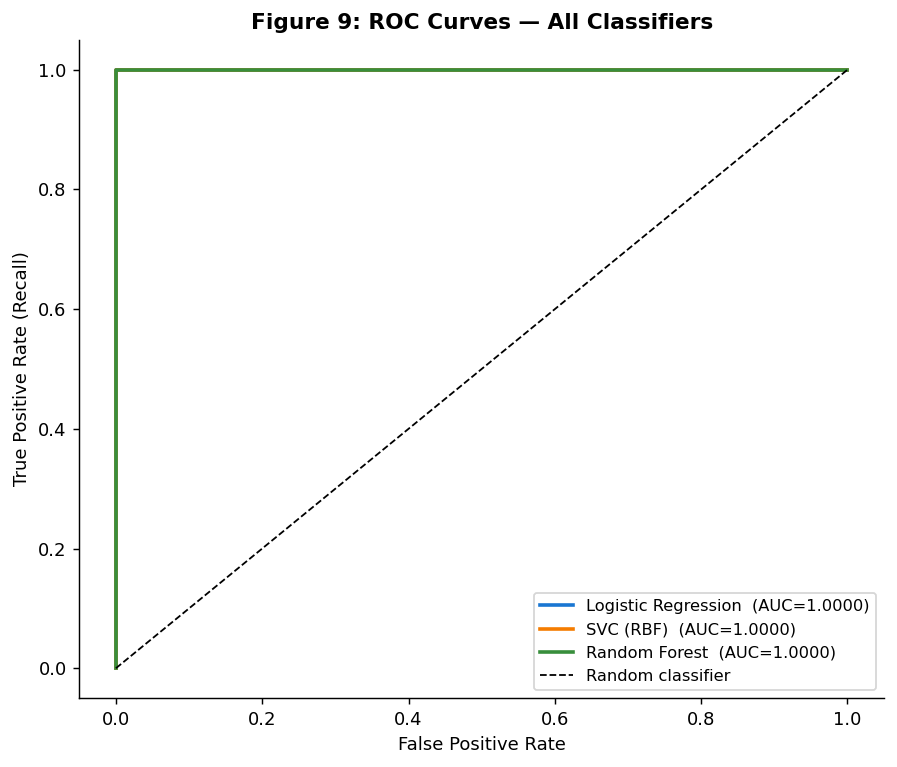

Saved: fig9_roc_curves_clf.png


In [30]:
# ── ROC Curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
roc_models = [
    ('Logistic Regression', y_prob_lr_clf,  '#1976D2'),
    ('SVC (RBF)',            y_prob_svc,    '#F57C00'),
    ('Random Forest',        y_prob_rf_clf, '#388E3C')
]

for name, y_prob, color in roc_models:
    fpr, tpr, _ = roc_curve(y_te_m, y_prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc(fpr, tpr):.4f})',
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Figure 9: ROC Curves — All Classifiers', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig9_roc_curves_clf.png', bbox_inches='tight')
plt.show()
print("Saved: fig9_roc_curves_clf.png")

---
## 3. Supervised Learning (Regression)

**Research question:** Which player attributes most strongly determine a footballer's market
value, and which regression model best predicts it?


### 3.2 Data Description

In [31]:
# ── Prepare regression dataframe ─────────────────────────────────────────
reg_df = fifa.drop(columns=['player_id', 'player_name', 'nationality', 'club']).copy()

# Encode binary and ordinal categoricals
reg_df['injury_prone']        = (reg_df['injury_prone'] == 'Yes').astype(int)
reg_df['transfer_risk_level'] = reg_df['transfer_risk_level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2}
)
reg_df = pd.get_dummies(reg_df, columns=['position'], drop_first=True)

print(f"Regression dataset shape: {reg_df.shape}")
display(reg_df.describe().round(2))

Regression dataset shape: (2800, 19)


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
count,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00
mean,27.95,76.87,81.56,27.14,19.26,12.02,2250.10,90.57,2.53,0.24,0.75
std,6.75,9.92,9.76,15.98,11.57,7.19,1295.46,52.08,1.70,0.43,0.77
min,17.00,60.00,65.00,0.00,0.00,0.00,0.00,0.67,0.00,0.00,0.00
25%,22.00,68.00,73.00,13.75,9.00,6.00,1131.25,45.36,1.00,0.00,0.00
50%,28.00,77.00,82.00,27.00,19.00,12.00,2251.00,89.17,3.00,0.00,1.00
75%,34.00,85.00,90.00,41.00,30.00,18.00,3366.25,136.68,4.00,0.00,1.00
max,39.00,94.00,98.00,54.00,39.00,24.00,4497.00,179.96,5.00,1.00,2.00


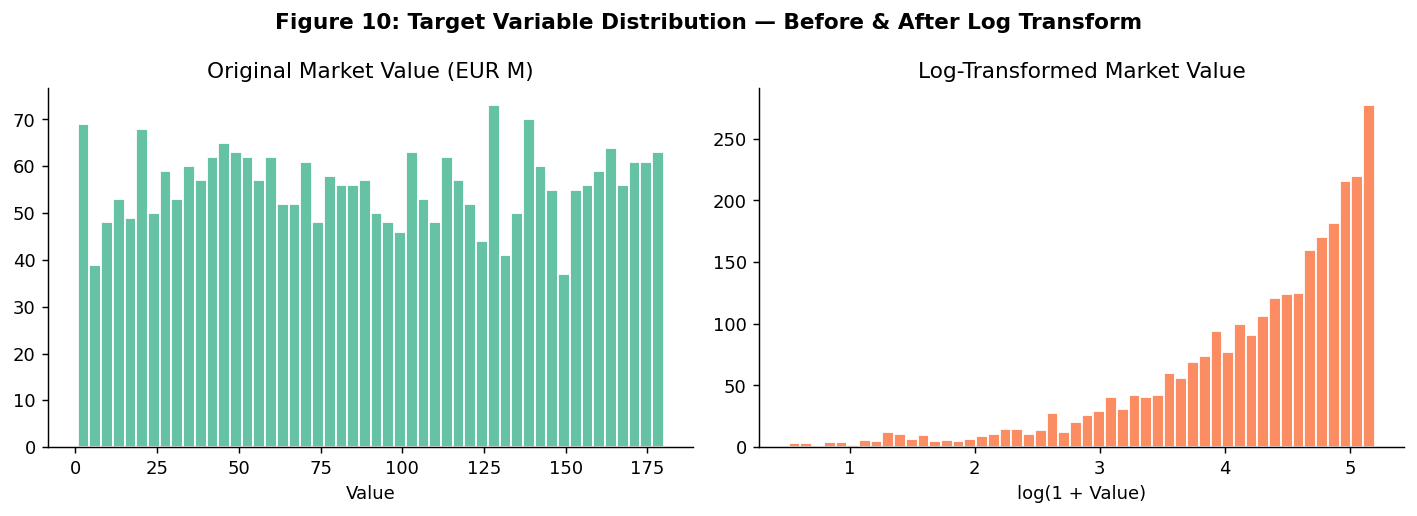

Saved: fig10_target_distribution.png


In [32]:
# ── Log-transform target to address right-skew ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(reg_df['market_value_million_eur'], bins=50,
             color=PALETTE[0], edgecolor='white')
axes[0].set_title('Original Market Value (EUR M)')
axes[0].set_xlabel('Value')

reg_df['log_market_value'] = np.log1p(reg_df['market_value_million_eur'])

axes[1].hist(reg_df['log_market_value'], bins=50,
             color=PALETTE[1], edgecolor='white')
axes[1].set_title('Log-Transformed Market Value')
axes[1].set_xlabel('log(1 + Value)')

plt.suptitle('Figure 10: Target Variable Distribution — Before & After Log Transform',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_target_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: fig10_target_distribution.png")

In [33]:
# ── Feature / target split + train-test split ────────────────────────────
FEAT_COLS = [c for c in reg_df.columns
             if c not in ['market_value_million_eur', 'log_market_value']]

X_reg = reg_df[FEAT_COLS]
y_reg = reg_df['log_market_value']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Train: {X_tr_r.shape[0]:,} | Test: {X_te_r.shape[0]:,} | Features: {X_tr_r.shape[1]}")

Train: 2,240 | Test: 560 | Features: 18


### 3.4.1 Linear Regression (Base and Polynomial)

In [34]:
# ── Base OLS ──────────────────────────────────────────────────────────────
ols = LinearRegression()
ols.fit(X_tr_r, y_tr_r)
y_pred_ols = ols.predict(X_te_r)

rmse_ols = np.sqrt(mean_squared_error(y_te_r, y_pred_ols))
mae_ols  = mean_absolute_error(y_te_r, y_pred_ols)
r2_ols   = r2_score(y_te_r, y_pred_ols)

print(f"OLS Linear Regression")
print(f"  RMSE: {rmse_ols:.4f}  |  MAE: {mae_ols:.4f}  |  R²: {r2_ols:.4f}")

OLS Linear Regression
  RMSE: 0.8917  |  MAE: 0.6962  |  R²: -0.0090


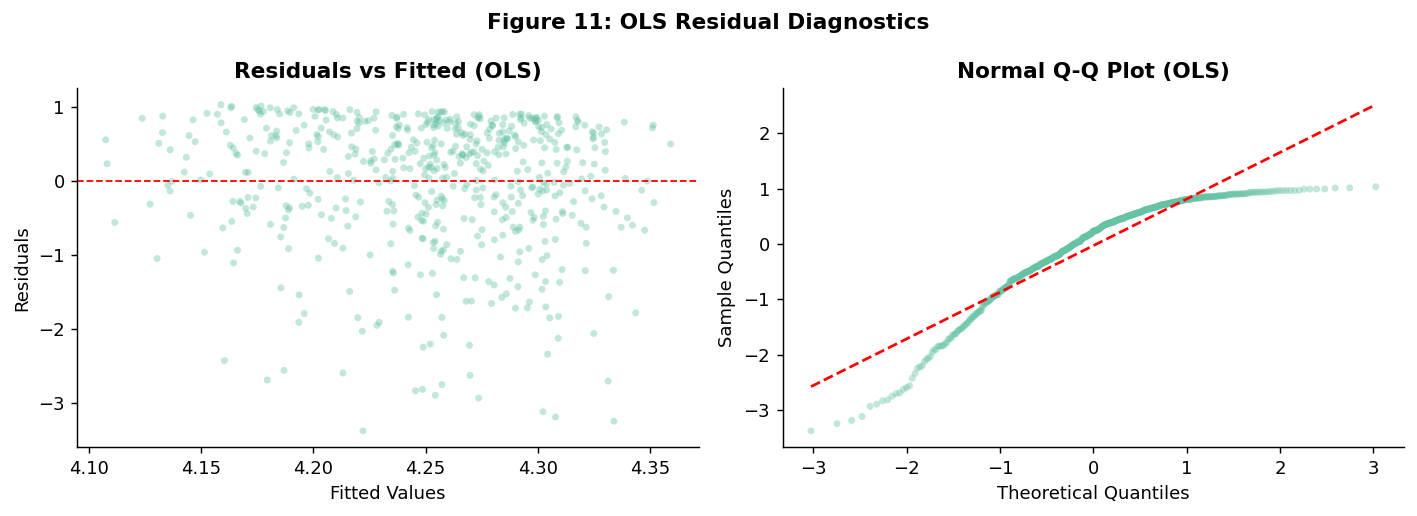

Saved: fig11_ols_residuals.png


In [35]:
# ── OLS residual diagnostics ─────────────────────────────────────────────
residuals_ols = y_te_r.values - y_pred_ols
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_pred_ols, residuals_ols, alpha=0.4, s=15,
                color=PALETTE[0], edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (OLS)', fontweight='bold')

(osm, osr), (slope, intercept, _) = stats.probplot(residuals_ols, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=15, color=PALETTE[0], edgecolors='none')
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('Normal Q-Q Plot (OLS)', fontweight='bold')

plt.suptitle('Figure 11: OLS Residual Diagnostics', fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_ols_residuals.png', bbox_inches='tight')
plt.show()
print("Saved: fig11_ols_residuals.png")

In [36]:
# ── Polynomial Regression (degree 2) ─────────────────────────────────────
poly     = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_tr_r)
X_te_poly  = poly.transform(X_te_r)

print(f"Original features     : {X_tr_r.shape[1]}")
print(f"Polynomial features   : {X_tr_poly.shape[1]}")

ols_poly      = LinearRegression()
ols_poly.fit(X_tr_poly, y_tr_r)
y_pred_poly   = ols_poly.predict(X_te_poly)

rmse_poly      = np.sqrt(mean_squared_error(y_te_r, y_pred_poly))
mae_poly       = mean_absolute_error(y_te_r, y_pred_poly)
r2_poly        = r2_score(y_te_r, y_pred_poly)
r2_poly_train  = r2_score(y_tr_r, ols_poly.predict(X_tr_poly))

print(f"\nPolynomial Regression (degree=2)")
print(f"  Train R² : {r2_poly_train:.4f}")
print(f"  Test  R² : {r2_poly:.4f}")
print(f"  RMSE     : {rmse_poly:.4f}  |  MAE: {mae_poly:.4f}")
if r2_poly_train - r2_poly > 0.1:
    print("  ⚠ Large train-test R² gap detected → overfitting, use regularisation")

Original features     : 18
Polynomial features   : 189

Polynomial Regression (degree=2)
  Train R² : 0.0685
  Test  R² : -0.0991
  RMSE     : 0.9306  |  MAE: 0.7231
  ⚠ Large train-test R² gap detected → overfitting, use regularisation


### 3.4.2 Regularization Regression (Lasso and Ridge)

In [37]:
# ── Ridge (L2) with cross-validated alpha ────────────────────────────────
alphas    = np.logspace(-3, 3, 100)
ridge_cv  = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_tr_poly, y_tr_r)
y_pred_ridge = ridge_cv.predict(X_te_poly)

rmse_ridge = np.sqrt(mean_squared_error(y_te_r, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_te_r, y_pred_ridge)
r2_ridge   = r2_score(y_te_r, y_pred_ridge)

print(f"Ridge Regression")
print(f"  Best alpha : {ridge_cv.alpha_:.4f}")
print(f"  RMSE: {rmse_ridge:.4f}  |  MAE: {mae_ridge:.4f}  |  R²: {r2_ridge:.4f}")

Ridge Regression
  Best alpha : 1000.0000
  RMSE: 0.9125  |  MAE: 0.7083  |  R²: -0.0568


In [38]:
# ── Lasso (L1) with cross-validated alpha ────────────────────────────────
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_tr_poly, y_tr_r)
y_pred_lasso = lasso_cv.predict(X_te_poly)

rmse_lasso = np.sqrt(mean_squared_error(y_te_r, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_te_r, y_pred_lasso)
r2_lasso   = r2_score(y_te_r, y_pred_lasso)

n_nonzero = (lasso_cv.coef_ != 0).sum()
print(f"Lasso Regression")
print(f"  Best alpha         : {lasso_cv.alpha_:.4f}")
print(f"  Non-zero features  : {n_nonzero} / {len(lasso_cv.coef_)}")
print(f"  RMSE: {rmse_lasso:.4f}  |  MAE: {mae_lasso:.4f}  |  R²: {r2_lasso:.4f}")

Lasso Regression
  Best alpha         : 1000.0000
  Non-zero features  : 1 / 189
  RMSE: 0.8885  |  MAE: 0.6939  |  R²: -0.0020


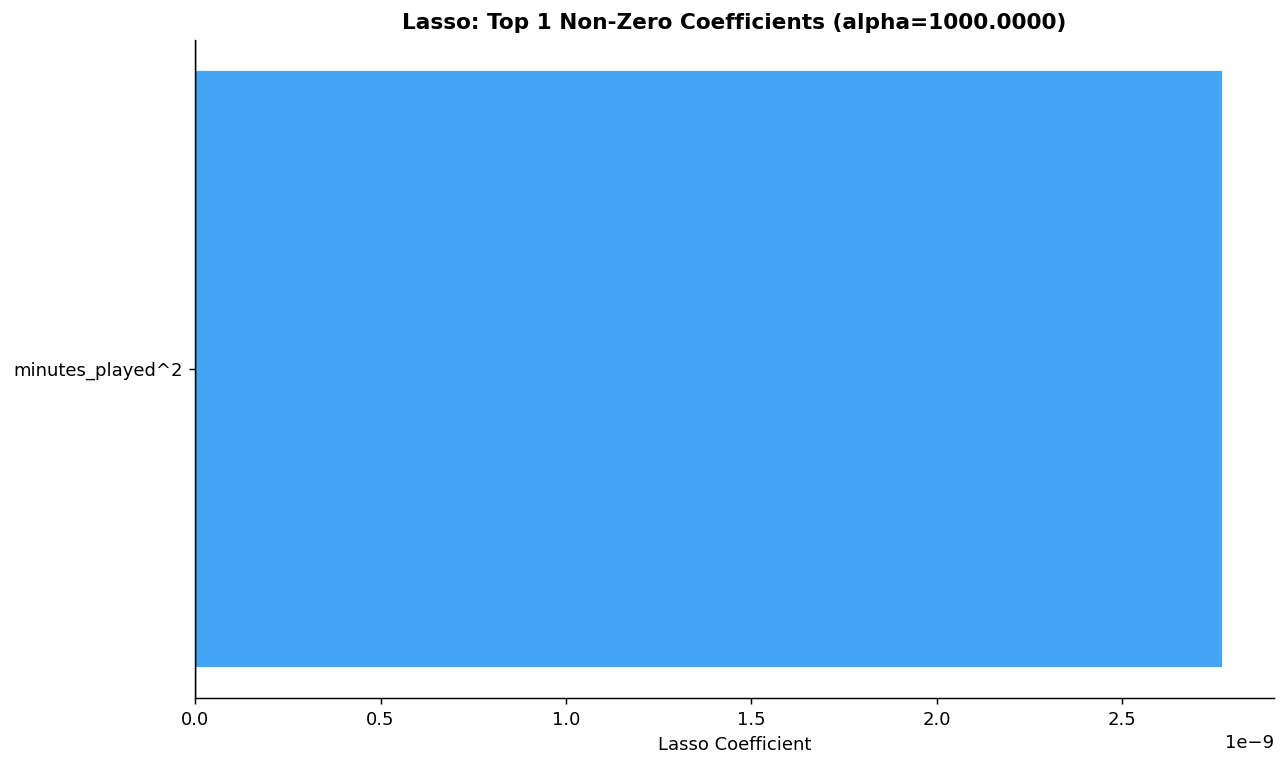

Saved: fig_lasso_coefficients.png


In [39]:
# ── Lasso non-zero coefficients ───────────────────────────────────────────
poly_feat_names = poly.get_feature_names_out(FEAT_COLS)
lasso_coef = pd.Series(lasso_cv.coef_, index=poly_feat_names)
nonzero_coef = lasso_coef[lasso_coef != 0].sort_values()

top_n = min(20, len(nonzero_coef))
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#EF5350' if v < 0 else '#42A5F5'
          for v in nonzero_coef.tail(top_n).values]
ax.barh(nonzero_coef.tail(top_n).index,
        nonzero_coef.tail(top_n).values,
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso: Top {top_n} Non-Zero Coefficients (alpha={lasso_cv.alpha_:.4f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lasso_coefficients.png', bbox_inches='tight')
plt.show()
print("Saved: fig_lasso_coefficients.png")

### 3.4.3 Random Forest Regressor

In [40]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr_r, y_tr_r)
y_pred_rf_reg = rf_reg.predict(X_te_r)

rmse_rf_reg = np.sqrt(mean_squared_error(y_te_r, y_pred_rf_reg))
mae_rf_reg  = mean_absolute_error(y_te_r, y_pred_rf_reg)
r2_rf_reg   = r2_score(y_te_r, y_pred_rf_reg)

print(f"Random Forest Regressor")
print(f"  RMSE: {rmse_rf_reg:.4f}  |  MAE: {mae_rf_reg:.4f}  |  R²: {r2_rf_reg:.4f}")

Random Forest Regressor
  RMSE: 0.9101  |  MAE: 0.7191  |  R²: -0.0510


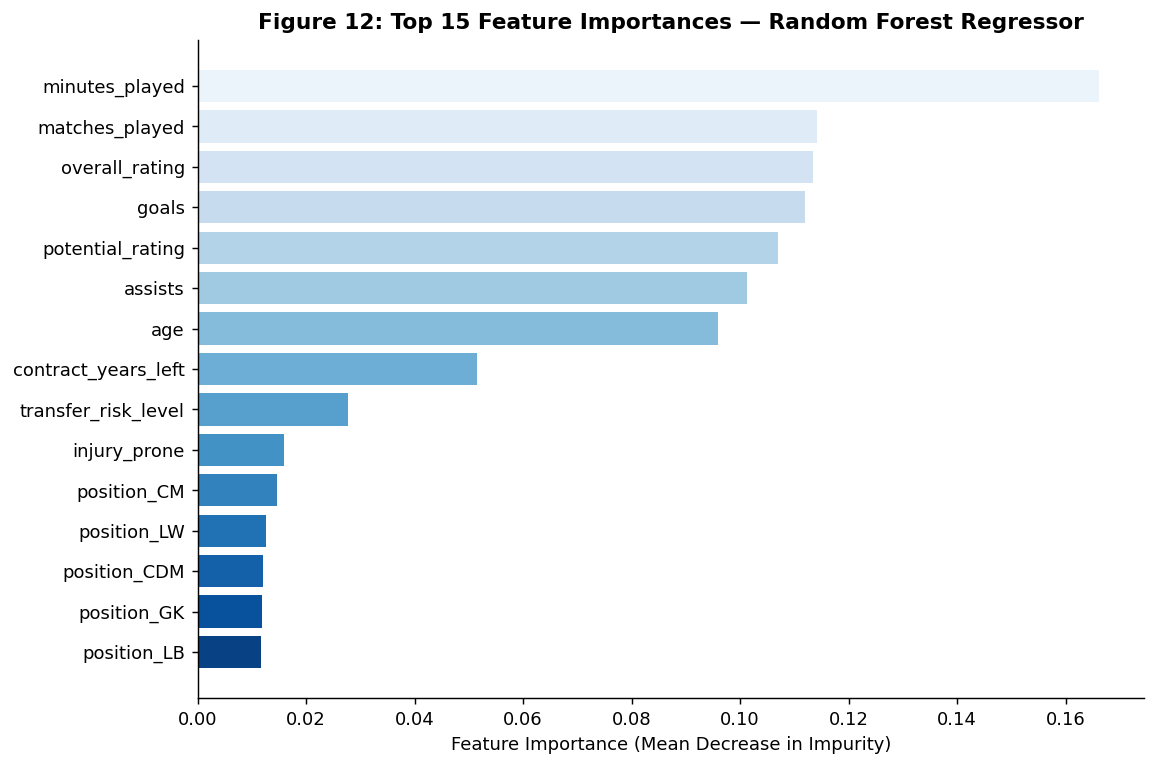

Saved: fig12_rf_feature_importance_reg.png


In [41]:
# ── Feature importance ────────────────────────────────────────────────────
feat_imp_reg = pd.Series(
    rf_reg.feature_importances_, index=FEAT_COLS
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_reg.index, feat_imp_reg.values,
        color=sns.color_palette("Blues_r", 15))
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Figure 12: Top 15 Feature Importances — Random Forest Regressor',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_rf_feature_importance_reg.png', bbox_inches='tight')
plt.show()
print("Saved: fig12_rf_feature_importance_reg.png")

### 3.5 Model Evaluation

In [42]:
# ── Model comparison table (Table 6) ─────────────────────────────────────
results_reg = pd.DataFrame([
    {'Model': 'Linear Regression (OLS)', 'RMSE': rmse_ols,     'MAE': mae_ols,     'R²': r2_ols},
    {'Model': 'Polynomial Regression',   'RMSE': rmse_poly,    'MAE': mae_poly,    'R²': r2_poly},
    {'Model': 'Ridge Regression',        'RMSE': rmse_ridge,   'MAE': mae_ridge,   'R²': r2_ridge},
    {'Model': 'Lasso Regression',        'RMSE': rmse_lasso,   'MAE': mae_lasso,   'R²': r2_lasso},
    {'Model': 'Random Forest',           'RMSE': rmse_rf_reg,  'MAE': mae_rf_reg,  'R²': r2_rf_reg},
]).round(4).sort_values('R²', ascending=False).reset_index(drop=True)

print("=== Table 6: Regression Model Performance (Test Set, log-scale target) ===")
display(results_reg)

=== Table 6: Regression Model Performance (Test Set, log-scale target) ===


,Model,RMSE,MAE,R²
0,Lasso Regression,0.8885,0.6939,-0.0020
1,Linear Regression (OLS),0.8917,0.6962,-0.0090
2,Random Forest,0.9101,0.7191,-0.0510
3,Ridge Regression,0.9125,0.7083,-0.0568
4,Polynomial Regression,0.9306,0.7231,-0.0991


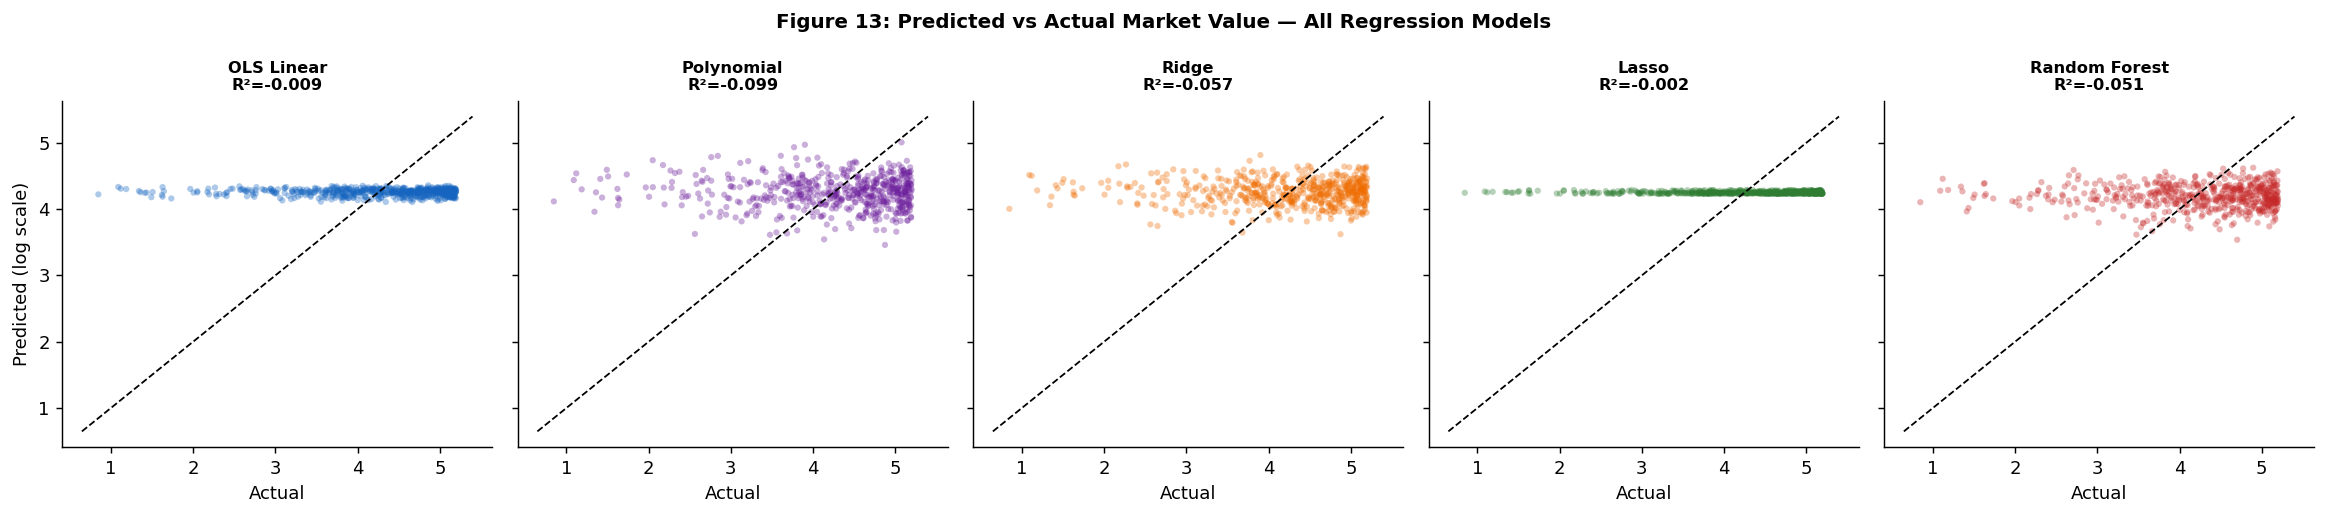

Saved: fig13_reg_predicted_vs_actual.png


In [43]:
# ── Predicted vs Actual — all 5 models (Figure 13) ───────────────────────
preds = [
    ('OLS Linear',    y_pred_ols,     '#1565C0'),
    ('Polynomial',    y_pred_poly,    '#6A1B9A'),
    ('Ridge',         y_pred_ridge,   '#EF6C00'),
    ('Lasso',         y_pred_lasso,   '#2E7D32'),
    ('Random Forest', y_pred_rf_reg,  '#C62828')
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, (name, y_pred, color) in zip(axes, preds):
    ax.scatter(y_te_r, y_pred, alpha=0.35, s=12,
               c=color, edgecolors='none')
    lims = [min(y_te_r.min(), y_pred.min()) - 0.2,
            max(y_te_r.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_title(f'{name}\nR²={r2_score(y_te_r, y_pred):.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Actual')
axes[0].set_ylabel('Predicted (log scale)')

plt.suptitle('Figure 13: Predicted vs Actual Market Value — All Regression Models',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_reg_predicted_vs_actual.png', bbox_inches='tight')
plt.show()
print("Saved: fig13_reg_predicted_vs_actual.png")

In [44]:
# ── 5-fold cross-validation on best model (Random Forest) ────────────────
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_reg, y_reg, cv=5, scoring='r2', n_jobs=-1
)
print(f"Random Forest — 5-Fold CV R² scores : {cv_scores.round(4)}")
print(f"Mean R²  : {cv_scores.mean():.4f}")
print(f"Std  R²  : {cv_scores.std():.4f}")

Random Forest — 5-Fold CV R² scores : [-0.0584 -0.0647 -0.0717 -0.033  -0.0769]
Mean R²  : -0.0610
Std  R²  : 0.0153


---
## Summary

Run all cells, then copy the printed metric values into the `[value]` placeholders in your Word report.

### Figures generated
| File | Figure in Report |
|------|-----------------|
| `fig1_feature_distributions.png` | Feature distributions |
| `fig1_correlation_heatmap.png` | Correlation heatmap |
| `fig2_elbow_silhouette.png` | Figure 2: Elbow & Silhouette |
| `fig3_cluster_boxplots.png` | Figure 3: Cluster Profiles (Boxplots) |
| `fig3b_cluster_radar.png` | Figure 3b: Cluster Profiles (Radar) |
| `fig4_kmeans_scatter.png` | Figure 4: K-Means Scatter (Rating vs Value) |
| `fig4b_kmeans_age_potential.png` | Figure 4b: K-Means Scatter (Age vs Potential) |
| `fig5_dendrogram.png` | Figure 5: HAC Dendrogram |
| `fig6_kmeans_vs_hac.png` | Figure 6: K-Means vs HAC Comparison |
| `fig7_rf_feature_importance_clf.png` | Figure 7: RF Feature Importance (Classification) |
| `fig8_confusion_matrices.png` | Figure 8: Confusion Matrices |
| `fig9_roc_curves_clf.png` | Figure 9: ROC Curves |
| `fig10_target_distribution.png` | Figure 10: Target Distribution |
| `fig11_ols_residuals.png` | Figure 11: OLS Residual Diagnostics |
| `fig12_rf_feature_importance_reg.png` | Figure 12: RF Feature Importance (Regression) |
| `fig13_reg_predicted_vs_actual.png` | Figure 13: Predicted vs Actual |

> **Remember:** Set `K_OPTIMAL` based on your elbow/silhouette output, and replace `[YOUR CANDIDATE NUMBER]` before submission.
